## In Linear Regression
-> Having more than 1 independent feature implies to multiple linear regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df_index = pd.read_csv('economic_index.csv')

In [5]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
# Drop unnecessary column
df_index.drop(columns=['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)

In [7]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
# Check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

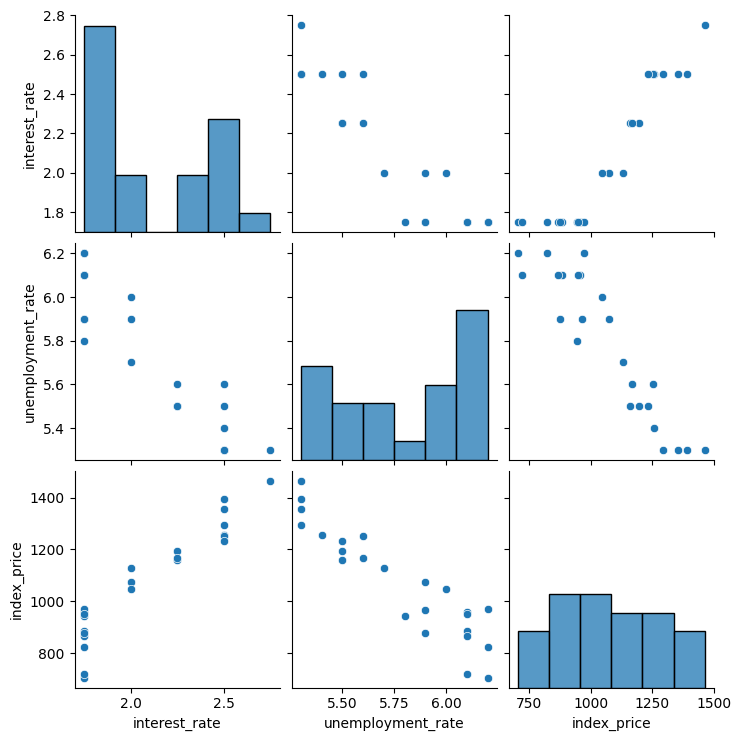

In [9]:
# Let's do some visualization
import seaborn as sns
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

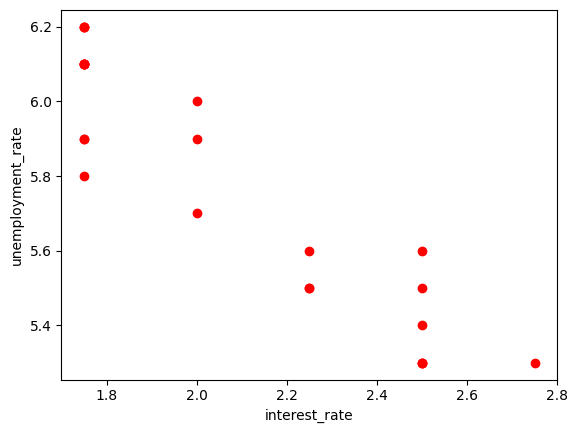

In [11]:
# Visualize the data points more closely

from turtle import color


plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color = 'r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

## Get Independent and Dependent Feature

In [12]:
# X = df_index[['interest_rate', 'unemployment_rate']] OR
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [13]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [14]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

## Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

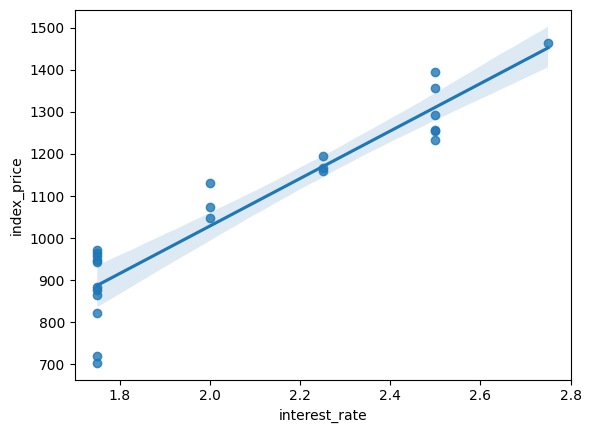

In [17]:
# One thing that seaborn allows a feature to plot data and a linear regression model fit
# But can't plot 3D plot i.e., only for 1 independent and 1 dependent feature
import seaborn as sns
sns.regplot(x = df_index['interest_rate'], y = df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

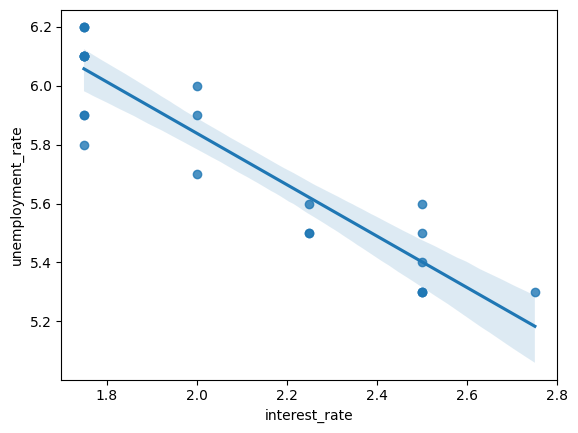

In [18]:
sns.regplot(x = df_index['interest_rate'], y = df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

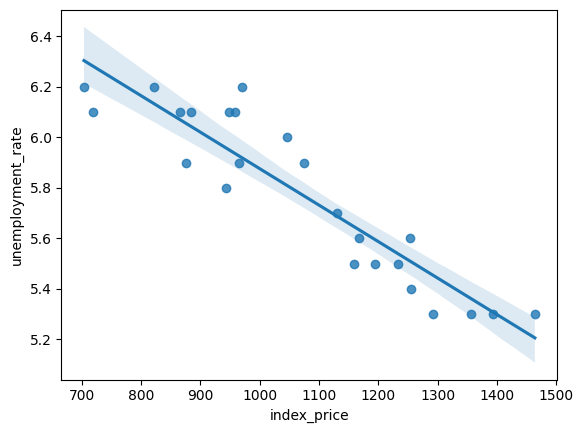

In [19]:
sns.regplot(x = df_index['index_price'], y = df_index['unemployment_rate'])

## Standard Scaling

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [23]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [24]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Cross Validation 
can use cross_val_score

1st parameter: model

2nd parameter: X (X_train)

3rd parameter: y (y_train)

4th parameter: scoring (There are many options for regression, can check in sklearn module cross_val_score, scoring section)

5th parameter : cv

When used, train data is split into train plus validate; validation data = (Total train/ cv)

If train = 900, cv = 5; validation data = (900/5) = 180

<pre>        ____________________
cv1:   |val|_______________|
cv2:   |___|val|___________|
cv3:   |_______|val|_______|
cv4:   |___________|val|___|
cv5:   |_______________|val|
<pre>

All cv will show respective -ve MSE values; we want -ve MSE -> 0; We will get the average of all the MSEs obtained and 
shown in the result

In [25]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)

In [26]:
np.mean(validation_score)

np.float64(-5914.828180162388)

## Prediction

In [27]:
y_pred = regression.predict(X_test)

In [28]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

## Performance Metrics

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
from traceback import print_tb


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  5793.762887712569
MAE:  59.935781523235484
RMSE:  76.11677139574805


In [31]:
# R2
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score: ", score)

R2 Score:  0.8278978091457145


In [32]:
# Adjusted R2
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.7131630152428576

# Assumptions

Finally, I should be able to find out whether my model is performing well or not

By seeing these assumptions, we can definitely come to a conclusion that my model will definitely perform well

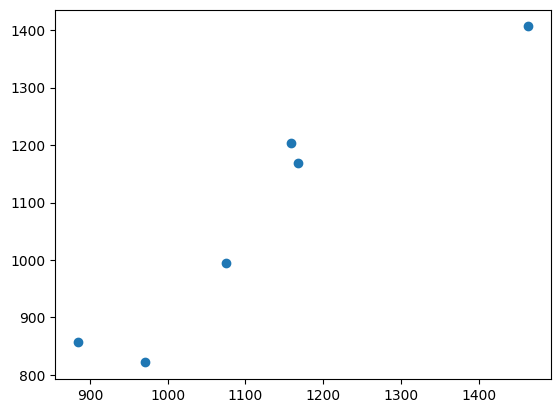

In [33]:
# 1st assumption

plt.scatter(y_test, y_pred) # Here, there is linear relationship

In [34]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


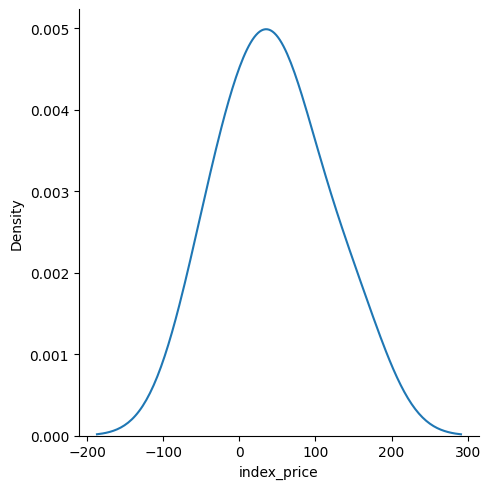

In [35]:
# Plot these residuals
sns.displot(residuals, kind = 'kde')
# If the output is like below, the model you have created is good

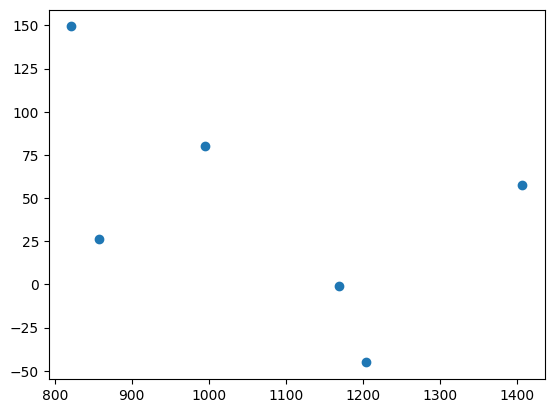

In [36]:
## Scatter plot with respect to predictions and residuals
plt.scatter(y_pred, residuals)

# In the output, the data is uniformly distributed as they didn't show any patterns as such

## OLS Linear Regression

In [37]:
import statsmodels.api as sm

In [38]:
model = sm.OLS(y_train, X_train).fit()

In [39]:
prediction = model.predict(X_test)
print(prediction)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [40]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 22 Aug 2026   Prob (F-statistic):                       0.754
Time:                        19:25:39   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [41]:
print(regression.coef_)

[  88.27275507 -116.25716066]


## Pickling

Python pickle module is used for serializing and de-serializing a Python object structure. Any object in python can be pickled so that it can be saved on disk. What pickle does is that it "serializes" the object first before writing it to file. Pickling is a way to convert a python object (list, dict, etc.) into a character stream. The idea is that this character stream contains all the information necessary to reconstruct the object in another python script.

In [42]:
import pickle
pickle.dump(regression, open('regressor.pkl', 'wb'))

In [43]:
model = pickle.load(open('regressor.pkl', 'rb'))

In [45]:
model.predict(X_test)

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])